# Cross-Sectional Dispersion Analysis

#### Observation: 
The MAG7 group have shown evidence of "fragementation" and separation over the past few years.

#### Hypothesis: 
In periods where cross-sectional variance of sentiment across MAG7 increases, subsequent cross-sectional return dispersion and/or pairwise correlation breakdown increases

#### Assumptions:
- Data Window: 02.23.2024 - 2.23.2026 (2-yrs)
- Daily Aggregation
- Neutral filtering

### Imports and Data Loading

In [335]:
import pandas as pd
from msa.utils.paths import get_joined_dataset

# Load joined price + news dataseta
INPUT_PATH = get_joined_dataset()

df_dates = pd.read_csv(
    INPUT_PATH,
    parse_dates=["date", "article_date", "price_date"]
)

# Required for analysis
required = ["sentiment_score", "ticker", "article_date", "price_date"]
missing = [c for c in required if c not in df_dates.columns]
assert not missing, f"Missing columns: {missing}"
# Logging
print(f"Loaded {len(df_dates):,} rows from {INPUT_PATH.name}")
print(f"Columns: {list(df_dates.columns)}")

Loaded 12,523 rows from gdelt_ohlcv_join.csv
Columns: ['seendate', 'url', 'title', 'language', 'domain', 'socialimage', 'company', 'ticker', 'date', 'sentiment_score', 'sentiment_hits', 'sentiment_present', 'article_date', 'price_date', 'next_open', 'next_high', 'next_low', 'next_close', 'next_adj_close', 'next_volume']


In [336]:
df_dates.info()

<class 'pandas.DataFrame'>
RangeIndex: 12523 entries, 0 to 12522
Data columns (total 20 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   seendate           12523 non-null  str           
 1   url                12523 non-null  str           
 2   title              12523 non-null  str           
 3   language           12523 non-null  str           
 4   domain             12523 non-null  str           
 5   socialimage        10625 non-null  str           
 6   company            12523 non-null  str           
 7   ticker             12523 non-null  str           
 8   date               7276 non-null   datetime64[us]
 9   sentiment_score    12523 non-null  float64       
 10  sentiment_hits     12523 non-null  float64       
 11  sentiment_present  12523 non-null  bool          
 12  article_date       12523 non-null  datetime64[us]
 13  price_date         12523 non-null  datetime64[us]
 14  next_open        

### Sentiment Metrics (incremental)
We'll build these step by step:
1. **Cross-sectional variance of sentiment** – variance of (mean sentiment per ticker) across MAG7 each day.
2. **Sentiment breadth** – share of MAG7 tickers with positive mean sentiment that day.
3. **Z-scored sentiment** – optional later (per-ticker z-score within rolling window).

First step below: daily aggregation per ticker, then dispersion metrics per day.

In [337]:
# MAG7 tickers and data window (per assumptions)
MAG7 = ["AAPL", "MSFT", "GOOGL", "AMZN", "NVDA", "META", "TSLA"]
WINDOW_START = "2024-02-23"
WINDOW_END = "2026-02-23"

print("="*70)
print("DATA FILTERING PIPELINE")
print("="*70)

# Step 1: Starting point
print(f"\n1. Initial dataset: {len(df_dates):,} rows")

# Step 2: Filter to MAG7 tickers
df_mag7_tickers = df_dates[df_dates["ticker"].isin(MAG7)].copy()
print(f"2. After MAG7 filter: {len(df_mag7_tickers):,} rows (-{len(df_dates) - len(df_mag7_tickers):,})")

# Step 3: Filter to time window
df_mag7 = df_mag7_tickers[
    (df_mag7_tickers["article_date"] >= WINDOW_START)
    & (df_mag7_tickers["article_date"] <= WINDOW_END)
].copy()
print(f"3. After date window filter ({WINDOW_START} to {WINDOW_END}): {len(df_mag7):,} rows (-{len(df_mag7_tickers) - len(df_mag7):,})")

# Step 4: Sentiment present filter
df_mag7_before_sentiment = df_mag7.copy()
df_mag7 = df_mag7[df_mag7["sentiment_present"]].copy()
print(f"4. After sentiment_present filter: {len(df_mag7):,} rows (-{len(df_mag7_before_sentiment) - len(df_mag7):,})")

# Step 5: Aggregate to daily ticker-level sentiment
daily_sentiment = (
    df_mag7.groupby(["article_date", "ticker"], as_index=False)["sentiment_score"]
    .mean()
    .rename(columns={"sentiment_score": "mean_sentiment"})
)
print(f"5. After daily aggregation (article_date × ticker): {len(daily_sentiment):,} rows")

# Step 6: Check daily coverage (how many days have sufficient ticker coverage)
daily_coverage = daily_sentiment.groupby("article_date")["ticker"].nunique().reset_index()
daily_coverage.columns = ["article_date", "n_tickers"]

print(f"\n   Daily ticker coverage distribution:")
print(f"   {daily_coverage['n_tickers'].value_counts().sort_index().to_dict()}")
print(f"\n   Days with >=5 tickers: {(daily_coverage['n_tickers'] >= 5).sum()} / {len(daily_coverage)} total days")
print(f"   Days with >=4 tickers: {(daily_coverage['n_tickers'] >= 4).sum()} / {len(daily_coverage)} total days")
print(f"   Days with >=3 tickers: {(daily_coverage['n_tickers'] >= 3).sum()} / {len(daily_coverage)} total days")

print("\n" + "="*70)
print("KEY DIAGNOSTICS")
print("="*70)

print(f"\nSentiment present statistics (in MAG7 + date window):")
print(f"  Articles with sentiment: {df_mag7['sentiment_present'].sum():,} / {len(df_mag7_before_sentiment):,} ({100*len(df_mag7)/len(df_mag7_before_sentiment):.1f}%)")
print(f"  Articles without sentiment: {(~df_mag7_before_sentiment['sentiment_present']).sum():,} ({100*(~df_mag7_before_sentiment['sentiment_present']).sum()/len(df_mag7_before_sentiment):.1f}%)")

print(f"\nSentiment score stats (articles with sentiment):")
print(df_mag7["sentiment_score"].describe())

print(f"\nDate range in filtered data:")
print(f"  First article: {df_mag7['article_date'].min()}")
print(f"  Last article: {df_mag7['article_date'].max()}")
print(f"  Unique days: {df_mag7['article_date'].nunique()}")

print("="*70)

daily_sentiment.head(10)

=== Sentiment Present Distribution ===
Total rows: 5,286

sentiment_present value counts:
sentiment_present
True    5286
Name: count, dtype: int64

sentiment_score stats:
count    5286.000000
mean        0.393341
std         0.709921
min        -1.000000
25%        -0.460000
50%         0.760000
75%         0.960000
max         0.960000
Name: sentiment_score, dtype: float64

Rows with sentiment_score = 0.0: 173
Rows with sentiment_present = False: 0
Daily ticker-level sentiment: 462 rows


,article_date,ticker,mean_sentiment
0,2024-04-07,GOOGL,0.691250
1,2024-04-07,META,0.496000
2,2024-04-08,AAPL,0.365556
3,2024-04-08,AMZN,0.499375
4,2024-04-08,GOOGL,0.657778
5,2024-04-08,META,0.530000
6,2024-04-08,MSFT,0.392500
7,2024-04-08,NVDA,0.630385
8,2024-04-08,TSLA,0.671111
9,2024-04-09,AAPL,0.760000


In [ ]:
# Per day: cross-sectional variance of mean sentiment across MAG7
def cross_sectional_variance(x):
    return x.var(ddof=0) if len(x) > 1 else 0.0

# Sentiment breadth: % of MAG7 tickers with positive mean sentiment
def sentiment_breadth(x):
    return (x > 0).mean() if len(x) > 0 else 0.0

# Sentiment dispersion metrics (before filtering)
sentiment_dispersion_all = daily_sentiment.groupby("article_date").agg(
    sent_var=("mean_sentiment", cross_sectional_variance),
    sent_breadth=("mean_sentiment", sentiment_breadth),
    sent_mean=("mean_sentiment", "mean"),
    n_tickers=("ticker", "nunique"),
).reset_index()

print("="*70)
print("SENTIMENT DISPERSION FILTERING")
print("="*70)

print(f"\n6. Before coverage filter: {len(sentiment_dispersion_all):,} days")
print(f"   Coverage distribution: {sentiment_dispersion_all['n_tickers'].value_counts().sort_index().to_dict()}")

# Apply minimum ticker coverage filter (5+ tickers for cross-sectional analysis)
MIN_TICKER_COVERAGE = 5
sentiment_dispersion = sentiment_dispersion_all[sentiment_dispersion_all["n_tickers"] >= MIN_TICKER_COVERAGE].copy()

print(f"\n7. After >=5 ticker filter: {len(sentiment_dispersion):,} days (-{len(sentiment_dispersion_all) - len(sentiment_dispersion):,})")
print(f"   {100*len(sentiment_dispersion)/len(sentiment_dispersion_all):.1f}% of days retained")

print("\n" + "="*70)

sentiment_dispersion.head(10)

,article_date,sent_var,sent_breadth,sent_mean,n_tickers
0,2024-04-07,0.009531,1.000000,0.593625,2
1,2024-04-08,0.013287,1.000000,0.535243,7
2,2024-04-09,0.031901,1.000000,0.749375,4
3,2024-07-04,0.000000,1.000000,0.871667,1
4,2024-07-05,0.038770,1.000000,0.386949,7
5,2024-07-06,0.000000,1.000000,0.910000,1
6,2024-07-08,0.230250,0.857143,0.344937,7
7,2024-07-09,0.000000,1.000000,0.666667,1
8,2024-07-10,0.000000,1.000000,0.657143,1
9,2024-09-05,0.000000,0.000000,0.000000,1


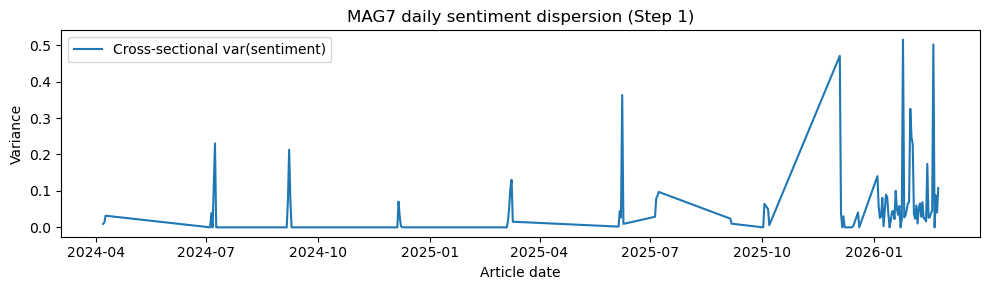

In [338]:
# Quick look: sentiment dispersion over time (cross-sectional variance)
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(sentiment_dispersion["article_date"], sentiment_dispersion["sent_var"], label="Cross-sectional var(sentiment)")
ax.set_xlabel("Article date")
ax.set_ylabel("Variance")
ax.legend()
ax.set_title("MAG7 daily sentiment dispersion (Step 1)")
plt.tight_layout()
plt.show()

**Next steps (incremental):**
- **Step 2** – Compute *subsequent* return dispersion: for each `article_date`, use `price_date` (next trading day) and `next_open`/`next_close` to get one-day returns per ticker; then cross-sectional variance of returns by day.
- **Step 3** – Align and test: merge sentiment dispersion (by `article_date`) with return dispersion (by `price_date`), then correlation or simple regression of return dispersion on lagged sentiment dispersion.

### Step 2: Return dispersion (following-day returns)
The join already attaches *next* trading day prices (`next_open`, `next_close`). We compute one-day returns per ticker and then cross-sectional variance of returns by `price_date`.

In [339]:
# Verify we have prices for every trading day in window
df_dates["price_date"].dt.date.value_counts().sort_index()
# Use MAG7 + window (no neutral filter) so we have returns for every trading day in range  

price_date
2024-02-09    182
2024-02-12     22
2024-04-08     23
2024-04-09    225
2024-04-10     27
             ... 
2026-02-18    233
2026-02-19    315
2026-02-20     11
2026-02-23    208
2026-02-24    168
Name: count, Length: 72, dtype: int64

In [340]:
# Use MAG7 + window (no neutral filter) so we have returns for every trading day in range
df_ret = df_dates[
    df_dates["ticker"].isin(MAG7)
    & (df_dates["article_date"] >= WINDOW_START)
    & (df_dates["article_date"] <= WINDOW_END)
].copy()

print("="*70)
print("RETURN DISPERSION CALCULATION")
print("="*70)

print(f"\n8. Rows for return calculation (MAG7 + date window, no sentiment filter): {len(df_ret):,}")

# Next-day return: (next_close - next_open) / next_open
df_ret["next_day_ret"] = (df_ret["next_close"] - df_ret["next_open"]) / df_ret["next_open"]

# One row per (price_date, ticker) — take first (all same return for that combo)
daily_returns = (
    df_ret[["price_date", "ticker", "next_day_ret"]]
    .drop_duplicates(subset=["price_date", "ticker"])
    .sort_values(["price_date", "ticker"])
)

print(f"9. Unique (price_date × ticker) pairs: {len(daily_returns):,}")

# Return dispersion by price_date: cross-sectional variance and mean return
return_dispersion_all = daily_returns.groupby("price_date").agg(
    ret_var=("next_day_ret", cross_sectional_variance),
    ret_mean=("next_day_ret", "mean"),
    n_tickers=("ticker", "nunique"),
).reset_index()

print(f"\n10. Before coverage filter: {len(return_dispersion_all):,} trading days")
print(f"    Coverage distribution: {return_dispersion_all['n_tickers'].value_counts().sort_index().to_dict()}")

# Apply minimum ticker coverage filter
return_dispersion = return_dispersion_all[return_dispersion_all["n_tickers"] >= MIN_TICKER_COVERAGE].copy()

print(f"\n11. After >=5 ticker filter: {len(return_dispersion):,} trading days (-{len(return_dispersion_all) - len(return_dispersion):,})")
print(f"    {100*len(return_dispersion)/len(return_dispersion_all):.1f}% of trading days retained")

print("\n" + "="*70)

return_dispersion.head(10)

Trading days with minimum 5 ticker MAG7 coverage: 43


,price_date,ret_var,ret_mean,n_tickers
1,2024-04-09,0.000186,-0.001553,7
4,2024-07-08,0.000157,-0.000446,7
5,2024-07-09,0.000338,0.003720,7
9,2024-09-09,0.000126,-0.001497,7
12,2024-12-09,0.000175,-0.000880,7
16,2025-03-10,0.001341,-0.033150,7
19,2025-06-09,0.000833,0.011466,7
21,2025-07-07,0.000055,-0.001801,7
22,2025-07-08,0.000092,-0.005140,7
24,2025-09-08,0.000076,-0.004513,7


In [341]:
# Align: sentiment on article_date t → returns on price_date (next trading day)
article_to_price = (
    df_mag7[["article_date", "price_date"]].drop_duplicates().sort_values("article_date")
)

print("="*70)
print("SENTIMENT-RETURN ALIGNMENT")
print("="*70)

print(f"\n12. Sentiment days available: {len(sentiment_dispersion):,}")
print(f"13. Return days available: {len(return_dispersion):,}")
print(f"14. Unique article_date → price_date mappings: {len(article_to_price):,}")

merged = (
    sentiment_dispersion.merge(article_to_price, on="article_date", how="inner")
    .merge(return_dispersion[["price_date", "ret_var", "ret_mean"]], on="price_date", how="inner")
)
merged = merged.sort_values("article_date").reset_index(drop=True)

print(f"\n15. Final aligned dataset: {len(merged):,} days")
print(f"    {100*len(merged)/len(sentiment_dispersion):.1f}% of sentiment days successfully aligned with returns")

print("\n" + "="*70)
print("COMPLETE DATA FLOW SUMMARY")
print("="*70)
print(f"""
Initial dataset:                12,523 rows
  ↓ MAG7 filter
  ↓ Date window filter
  ↓ sentiment_present filter
Filtered articles:              {len(df_mag7):,} rows
  ↓ Daily aggregation (article_date × ticker)
Daily sentiment pairs:          {len(daily_sentiment):,} pairs
  ↓ Cross-sectional metrics per day
Daily sentiment metrics:        {len(sentiment_dispersion_all):,} days
  ↓ >=5 ticker coverage filter
Sentiment dispersion (final):   {len(sentiment_dispersion):,} days ({100*len(sentiment_dispersion)/len(sentiment_dispersion_all):.1f}%)
  ↓ Align with returns
Final analysis dataset:         {len(merged):,} days ({100*len(merged)/len(sentiment_dispersion):.1f}%)
""")
print("="*70)

merged.head(10)

Aligned days (sentiment t → return on price_date): 72


,article_date,sent_var,sent_breadth,sent_mean,n_tickers,price_date,ret_var,ret_mean
0,2024-04-08,0.013287,1.000000,0.535243,7,2024-04-09,0.000186,-0.001553
1,2024-07-05,0.038770,1.000000,0.386949,7,2024-07-08,0.000157,-0.000446
2,2024-07-06,0.000000,1.000000,0.910000,1,2024-07-08,0.000157,-0.000446
3,2024-07-08,0.230250,0.857143,0.344937,7,2024-07-09,0.000338,0.003720
4,2024-09-06,0.073929,0.571429,0.140048,7,2024-09-09,0.000126,-0.001497
5,2024-09-07,0.212878,0.714286,0.137585,7,2024-09-09,0.000126,-0.001497
6,2024-09-08,0.075415,1.000000,0.576288,3,2024-09-09,0.000126,-0.001497
7,2024-12-06,0.070640,1.000000,0.616445,7,2024-12-09,0.000175,-0.000880
8,2024-12-07,0.027953,1.000000,0.719442,7,2024-12-09,0.000175,-0.000880
9,2024-12-08,0.003338,1.000000,0.867292,4,2024-12-09,0.000175,-0.000880


### Coverage Report

In [ ]:
# Coverage report showing dropoff from each filtering step


Neutral filtering removed 0 rows
Minimum 5 ticker filter removed 5,243 rows


### Descriptive analysis
Summary statistics, distributions, scatter (sentiment dispersion vs return dispersion), correlation matrix, and rolling correlation.

In [312]:
# Summary statistics for dispersion metrics
disp_cols = ["sent_var", "sent_breadth", "sent_mean", "ret_var", "ret_mean"]
merged[disp_cols].describe().round(6)

,sent_var,sent_breadth,sent_mean,ret_var,ret_mean
count,72.000000,72.000000,72.000000,72.000000,72.000000
mean,0.070446,0.902315,0.412479,0.000246,-0.001940
std,0.089044,0.151156,0.230278,0.000290,0.010710
min,0.000000,0.250000,-0.368523,0.000005,-0.033150
25%,0.026299,0.857143,0.265413,0.000110,-0.006248
50%,0.041983,1.000000,0.396739,0.000162,-0.001220
75%,0.074300,1.000000,0.563779,0.000198,0.006489
max,0.514837,1.000000,0.910000,0.001341,0.014539


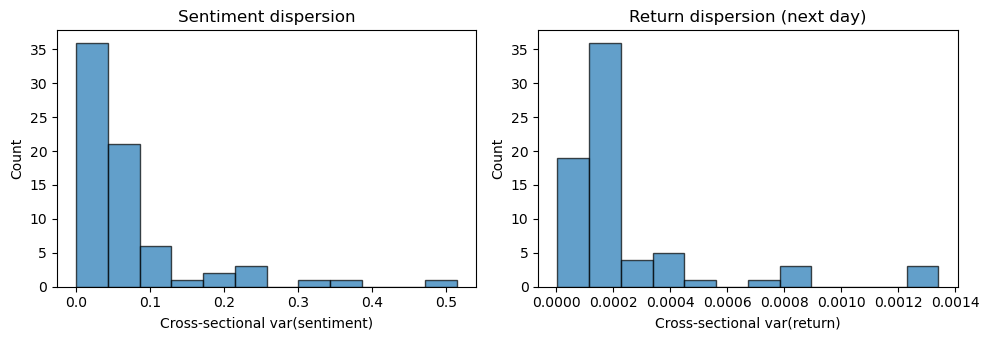

In [313]:
# Distribution plots: sentiment dispersion and return dispersion
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
axes[0].hist(merged["sent_var"], bins=12, edgecolor="k", alpha=0.7)
axes[0].set_xlabel("Cross-sectional var(sentiment)")
axes[0].set_ylabel("Count")
axes[0].set_title("Sentiment dispersion")
axes[1].hist(merged["ret_var"], bins=12, edgecolor="k", alpha=0.7)
axes[1].set_xlabel("Cross-sectional var(return)")
axes[1].set_ylabel("Count")
axes[1].set_title("Return dispersion (next day)")
plt.tight_layout()
plt.show()

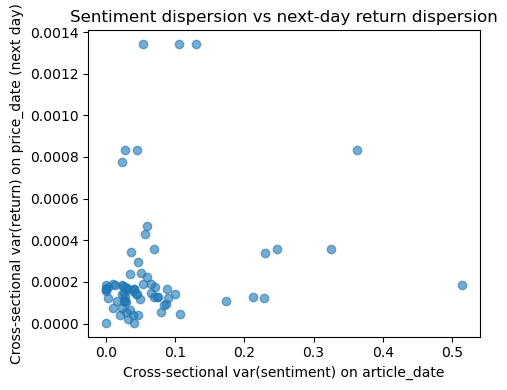

In [314]:
# Scatter: sentiment dispersion (t) vs return dispersion (next day)
plt.figure(figsize=(5, 4))
plt.scatter(merged["sent_var"], merged["ret_var"], alpha=0.6)
plt.xlabel("Cross-sectional var(sentiment) on article_date")
plt.ylabel("Cross-sectional var(return) on price_date (next day)")
plt.title("Sentiment dispersion vs next-day return dispersion")
plt.tight_layout()
plt.show()

In [315]:
# Correlation matrix
merged[disp_cols].corr().round(4)

,sent_var,sent_breadth,sent_mean,ret_var,ret_mean
sent_var,1.0000,-0.5587,-0.4213,0.1899,0.0593
sent_breadth,-0.5587,1.0000,0.7533,-0.2569,0.1503
sent_mean,-0.4213,0.7533,1.0000,-0.2844,0.0563
ret_var,0.1899,-0.2569,-0.2844,1.0000,-0.3318
ret_mean,0.0593,0.1503,0.0563,-0.3318,1.0000


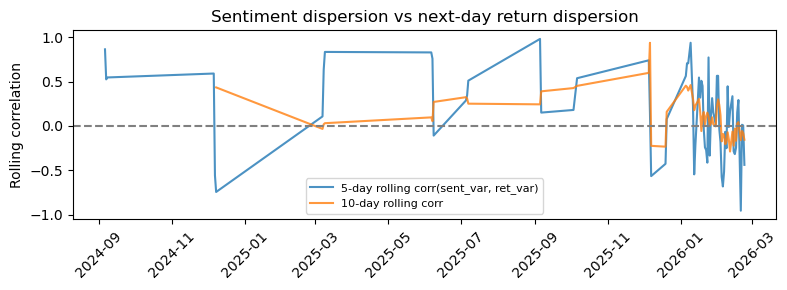

In [316]:
# Rolling correlation: sent_var vs ret_var (5-day and 10-day)
merged_ts = merged.set_index("article_date").sort_index()
merged_ts["roll_corr_5"] = merged_ts["sent_var"].rolling(5).corr(merged_ts["ret_var"])
merged_ts["roll_corr_10"] = merged_ts["sent_var"].rolling(10).corr(merged_ts["ret_var"])

fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(merged_ts.index, merged_ts["roll_corr_5"], label="5-day rolling corr(sent_var, ret_var)", alpha=0.8)
ax.plot(merged_ts.index, merged_ts["roll_corr_10"], label="10-day rolling corr", alpha=0.8)
ax.axhline(0, color="gray", linestyle="--")
ax.legend(loc="best", fontsize=8)
ax.set_ylabel("Rolling correlation")
ax.set_title("Sentiment dispersion vs next-day return dispersion")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Hypothesis evaluation: correlation patterns

Hypothesis: high sentiment dispersion → subsequent **return dispersion** (ret_var) and/or **pairwise correlation breakdown** (lower avg pairwise corr of MAG7 returns).

- **Return dispersion**: positive correlation of sent_var (or sent_breadth) with ret_var supports the hypothesis.
- **Pairwise correlation breakdown**: negative correlation of sent_var with avg pairwise return correlation supports the hypothesis (fragmented sentiment → stocks move more idiosyncratically).

In [317]:
import numpy as np
from msa.utils.paths import get_processed_data_path

# Pairwise correlation from FULL OHLCV (not join) so we have every trading day × MAG7, no NaNs
prices_path = get_processed_data_path() / "prices_daily_accumulated.csv"
ohlcv = pd.read_csv(prices_path, parse_dates=["date"])
ohlcv = ohlcv[
    ohlcv["ticker"].isin(MAG7)
    & (ohlcv["date"] >= WINDOW_START)
    & (ohlcv["date"] <= WINDOW_END)
].copy()
ohlcv["ret"] = (ohlcv["close"] - ohlcv["open"]) / ohlcv["open"]
wide_ret = ohlcv.pivot(index="date", columns="ticker", values="ret").sort_index()
wide_ret = wide_ret.dropna(how="any")  # require all 7 tickers per day

# Rolling pairwise correlation
ROLL = 10
pairwise_list = []
for i in range(ROLL - 1, len(wide_ret)):
    window = wide_ret.iloc[i - ROLL + 1 : i + 1]
    c = window.corr()
    tri = np.triu(np.ones_like(c, dtype=bool), k=1)
    pairwise_list.append((wide_ret.index[i], float(c.values[tri].mean())))
pairwise_df = pd.DataFrame(pairwise_list, columns=["price_date", "ret_pairwise_corr"])
pairwise_df["price_date"] = pd.to_datetime(pairwise_df["price_date"]).dt.normalize()

merged_eval = merged.merge(pairwise_df, on="price_date", how="inner")

### Time window expansion and regime analysis

Evaluate how pairwise correlation evolves as the time window expands. Use quantiles to detect structural regime changes (low/medium/high correlation periods).

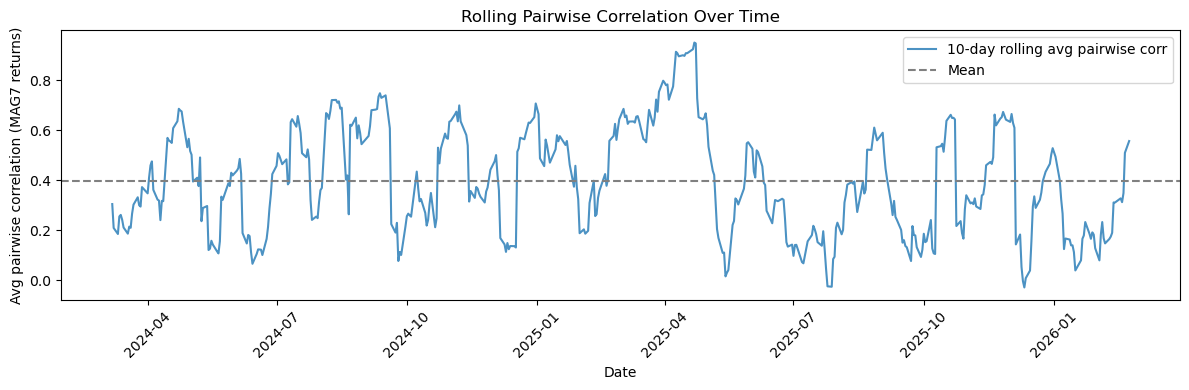

Mean pairwise corr: 0.3961
Std pairwise corr: 0.2117


In [318]:
# Plot rolling pairwise correlation over the full expanded period
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(pairwise_df["price_date"], pairwise_df["ret_pairwise_corr"], label="10-day rolling avg pairwise corr", alpha=0.8)
ax.axhline(pairwise_df["ret_pairwise_corr"].mean(), color="gray", linestyle="--", label="Mean")
ax.set_xlabel("Date")
ax.set_ylabel("Avg pairwise correlation (MAG7 returns)")
ax.set_title("Rolling Pairwise Correlation Over Time")
ax.legend(loc="best")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(f"Mean pairwise corr: {pairwise_df['ret_pairwise_corr'].mean():.4f}")
print(f"Std pairwise corr: {pairwise_df['ret_pairwise_corr'].std():.4f}")

In [319]:
# Quantile-based regime detection (tertiles: low/medium/high correlation)
q33 = pairwise_df["ret_pairwise_corr"].quantile(0.33)
q67 = pairwise_df["ret_pairwise_corr"].quantile(0.67)

pairwise_df["regime"] = pd.cut(
    pairwise_df["ret_pairwise_corr"],
    bins=[-np.inf, q33, q67, np.inf],
    labels=["low_corr", "medium_corr", "high_corr"]
)

print("Regime thresholds (tertiles):")
print(f"  Low correlation:    ret_pairwise_corr < {q33:.4f}")
print(f"  Medium correlation: {q33:.4f} <= ret_pairwise_corr < {q67:.4f}")
print(f"  High correlation:   ret_pairwise_corr >= {q67:.4f}")
print()
print("Regime distribution:")
print(pairwise_df["regime"].value_counts().sort_index())

Regime thresholds (tertiles):
  Low correlation:    ret_pairwise_corr < 0.2665
  Medium correlation: 0.2665 <= ret_pairwise_corr < 0.5196
  High correlation:   ret_pairwise_corr >= 0.5196

Regime distribution:
regime
low_corr       163
medium_corr    166
high_corr      163
Name: count, dtype: int64


In [320]:
# Merge regime info into main evaluation dataframe
merged_eval_regime = merged_eval.merge(
    pairwise_df[["price_date", "regime"]], 
    on="price_date", 
    how="inner"
)

# Conditional analysis by regime
print("Hypothesis evaluation by correlation regime:")
print("=" * 70)

for regime in ["low_corr", "medium_corr", "high_corr"]:
    subset = merged_eval_regime[merged_eval_regime["regime"] == regime]
    n = len(subset)
    
    if n < 5:
        print(f"\n{regime.upper()} ({n} obs): Insufficient data for correlation")
        continue
    
    corr_sv_rv = subset["sent_var"].corr(subset["ret_var"])
    corr_sv_pc = subset["sent_var"].corr(subset["ret_pairwise_corr"])
    corr_sb_rv = subset["sent_breadth"].corr(subset["ret_var"])
    corr_sb_pc = subset["sent_breadth"].corr(subset["ret_pairwise_corr"])
    
    print(f"\n{regime.upper()} ({n} obs):")
    print(f"  corr(sent_var, ret_var)           = {corr_sv_rv:+.4f}")
    print(f"  corr(sent_var, ret_pairwise_corr) = {corr_sv_pc:+.4f}")
    print(f"  corr(sent_breadth, ret_var)       = {corr_sb_rv:+.4f}")
    print(f"  corr(sent_breadth, ret_pairwise_corr) = {corr_sb_pc:+.4f}")

Hypothesis evaluation by correlation regime:

LOW_CORR (42 obs):
  corr(sent_var, ret_var)           = +0.1160
  corr(sent_var, ret_pairwise_corr) = -0.0841
  corr(sent_breadth, ret_var)       = -0.2056
  corr(sent_breadth, ret_pairwise_corr) = +0.1750

MEDIUM_CORR (20 obs):
  corr(sent_var, ret_var)           = +0.4652
  corr(sent_var, ret_pairwise_corr) = +0.2904
  corr(sent_breadth, ret_var)       = +0.0628
  corr(sent_breadth, ret_pairwise_corr) = +0.0909

HIGH_CORR (9 obs):
  corr(sent_var, ret_var)           = +0.1061
  corr(sent_var, ret_pairwise_corr) = +0.5697
  corr(sent_breadth, ret_var)       = -0.4639
  corr(sent_breadth, ret_pairwise_corr) = -0.6042


In [ ]:
# Rolling window comparison: early vs late period
midpoint = pairwise_df["price_date"].quantile(0.5)
early = merged_eval[merged_eval["price_date"] < midpoint]
late = merged_eval[merged_eval["price_date"] >= midpoint]

print("Rolling window comparison (early vs late period):")
print("=" * 70)
print(f"Midpoint: {midpoint.date()}")
print(f"\nEARLY PERIOD ({len(early)} obs, up to {early['price_date'].max().date()}):")
print(f"  corr(sent_var, ret_var)           = {early['sent_var'].corr(early['ret_var']):+.4f}")
print(f"  corr(sent_var, ret_pairwise_corr) = {early['sent_var'].corr(early['ret_pairwise_corr']):+.4f}")
print(f"  mean(ret_pairwise_corr)           = {early['ret_pairwise_corr'].mean():.4f}")

print(f"\nLATE PERIOD ({len(late)} obs, from {late['price_date'].min().date()}):")
print(f"  corr(sent_var, ret_var)           = {late['sent_var'].corr(late['ret_var']):+.4f}")
print(f"  corr(sent_var, ret_pairwise_corr) = {late['sent_var'].corr(late['ret_pairwise_corr']):+.4f}")
print(f"  mean(ret_pairwise_corr)           = {late['ret_pairwise_corr'].mean():.4f}")

Rolling window comparison (early vs late period):
Midpoint: 2025-03-01

EARLY PERIOD (7 obs, up to 2024-12-09):
  corr(sent_var, ret_var)           = -0.0404
  corr(sent_var, ret_pairwise_corr) = +0.5675
  mean(ret_pairwise_corr)           = 0.4055

LATE PERIOD (47 obs, from 2025-03-10):
  corr(sent_var, ret_var)           = -0.0716
  corr(sent_var, ret_pairwise_corr) = -0.1089
  mean(ret_pairwise_corr)           = 0.2393


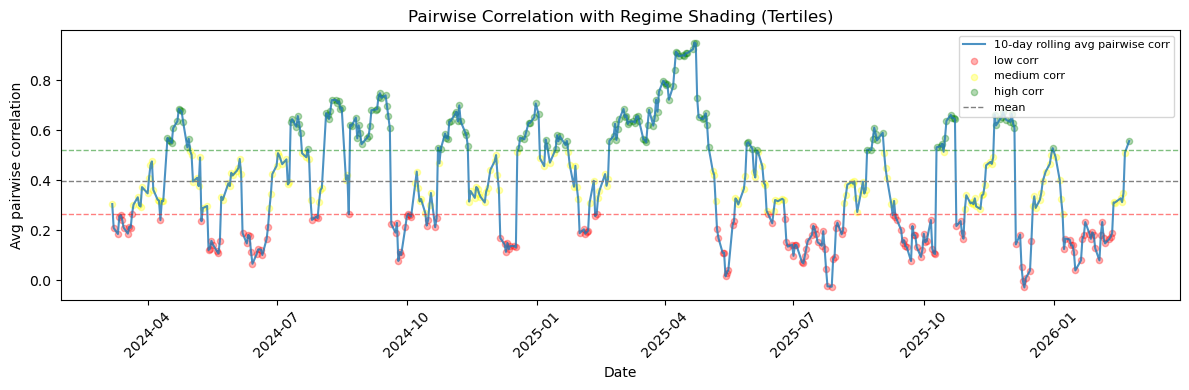

In [321]:
# Visualization: pairwise correlation with regime shading
fig, ax = plt.subplots(figsize=(12, 4))

# Plot pairwise correlation
ax.plot(pairwise_df["price_date"], pairwise_df["ret_pairwise_corr"], 
        label="10-day rolling avg pairwise corr", alpha=0.8, linewidth=1.5)

# Add regime shading
regime_colors = {"low_corr": "red", "medium_corr": "yellow", "high_corr": "green"}
for regime, color in regime_colors.items():
    regime_data = pairwise_df[pairwise_df["regime"] == regime]
    ax.scatter(regime_data["price_date"], regime_data["ret_pairwise_corr"], 
               c=color, alpha=0.3, s=20, label=f"{regime.replace('_', ' ')}")

# Add quantile lines
ax.axhline(q33, color="red", linestyle="--", alpha=0.5, linewidth=1)
ax.axhline(q67, color="green", linestyle="--", alpha=0.5, linewidth=1)
ax.axhline(pairwise_df["ret_pairwise_corr"].mean(), color="gray", linestyle="--", linewidth=1, label="mean")

ax.set_xlabel("Date")
ax.set_ylabel("Avg pairwise correlation")
ax.set_title("Pairwise Correlation with Regime Shading (Tertiles)")
ax.legend(loc="best", fontsize=8)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### Interpretation

- **Regime analysis**: The tertile-based regimes (low/medium/high correlation) allow us to test whether the sentiment-dispersion hypothesis holds differently in different market correlation environments.
- **Rolling window comparison**: Splitting the data at the midpoint helps identify whether correlations are stable or shifting over time (potential structural change).
- **Visualization**: The regime-shaded plot highlights periods of high vs. low pairwise correlation, making regime transitions visually apparent.

**Next steps (optional)**: For formal change-point detection, consider using methods like rolling standard deviation of pairwise correlation, or statistical tests (e.g., Chow test, CUSUM).

In [322]:
# Key correlations for hypothesis evaluation
print("Hypothesis: sent_var / sent_breadth → ret_var (return dispersion) or → pairwise correlation breakdown")
print()
print("1. Return dispersion (ret_var):")
print(f"   corr(sent_var, ret_var)  = {merged_eval['sent_var'].corr(merged_eval['ret_var']):.4f}")
print(f"   corr(sent_breadth, ret_var) = {merged_eval['sent_breadth'].corr(merged_eval['ret_var']):.4f}")
print()
print("2. Pairwise correlation breakdown (lower ret_pairwise_corr = breakdown):")
print(f"   corr(sent_var, ret_pairwise_corr) = {merged_eval['sent_var'].corr(merged_eval['ret_pairwise_corr']):.4f}")
print(f"   corr(sent_breadth, ret_pairwise_corr) = {merged_eval['sent_breadth'].corr(merged_eval['ret_pairwise_corr']):.4f}")
print()
print("Support for hypothesis: positive sent_var→ret_var, negative sent_var→ret_pairwise_corr")

Hypothesis: sent_var / sent_breadth → ret_var (return dispersion) or → pairwise correlation breakdown

1. Return dispersion (ret_var):
   corr(sent_var, ret_var)  = 0.1950
   corr(sent_breadth, ret_var) = -0.2608

2. Pairwise correlation breakdown (lower ret_pairwise_corr = breakdown):
   corr(sent_var, ret_pairwise_corr) = 0.0626
   corr(sent_breadth, ret_pairwise_corr) = -0.1347

Support for hypothesis: positive sent_var→ret_var, negative sent_var→ret_pairwise_corr


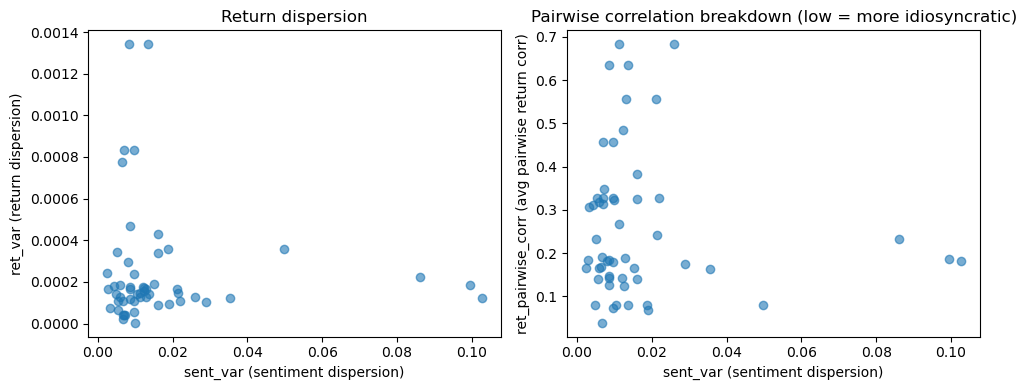

In [ ]:
# Scatter: sentiment dispersion vs pairwise correlation (breakdown = lower corr)
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].scatter(merged_eval["sent_var"], merged_eval["ret_var"], alpha=0.6)
axes[0].set_xlabel("sent_var (sentiment dispersion)")
axes[0].set_ylabel("ret_var (return dispersion)")
axes[0].set_title("Return dispersion")
axes[1].scatter(merged_eval["sent_var"], merged_eval["ret_pairwise_corr"], alpha=0.6)
axes[1].set_xlabel("sent_var (sentiment dispersion)")
axes[1].set_ylabel("ret_pairwise_corr (avg pairwise return corr)")
axes[1].set_title("Pairwise correlation breakdown (low = more idiosyncratic)")
plt.tight_layout()
plt.show()